# INVERTER CIRCUIT 7nm FINFET

> Path: /home/eduarda/Repos/Electrical-Behaviour-Prediction/FINFET/7nm/NOT/Data/sim1/simResults_NOTfet/all_results_inverter.csv

> https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction/tree/main/FINFET

## Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '/home/eduarda/Repos/jupyter_ic/data/raw/FINFET/7nm/NOT/sim1/all_results_inverter.csv'
plots_dir = "../../../../figures/FINFET/7nm/NOT/01_data_exploration/"
data = pd.read_csv(path, index_col=0)

In [3]:
data = data.rename(columns={
    '1': 'nfet@var', 
    '2': 'pfet@var', 
    'vdd': 'voltage', 
    'LoadCap': 'capacitance',
    'number_fin': 'finsNumber',
})

data

,nfet@var,pfet@var,capacitance,voltage,finsNumber,index,temp,montecarlo_iteration,tphl,tplh,total_power,iint,temper,alter#
0,4.370067,4.852864,1f,0.6,1,1,-25,1,1.230100e-11,1.582600e-11,-9.601460e-09,-6.400970e-16,-25,1
1,4.370806,4.873612,1f,0.6,1,2,-25,2,1.232850e-11,1.470250e-11,-9.648810e-09,-6.432540e-16,-25,1
2,4.333499,4.850897,1f,0.6,1,3,-25,3,1.128970e-11,1.594150e-11,-9.603980e-09,-6.402650e-16,-25,1
3,4.407237,4.856645,1f,0.6,1,4,-25,4,1.353270e-11,1.560170e-11,-9.595290e-09,-6.396860e-16,-25,1
4,4.387795,4.770993,1f,0.6,1,5,-25,5,1.282430e-11,2.289280e-11,-9.530360e-09,-6.353580e-16,-25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,4.336670,4.776053,16f,0.9,5,596,100,96,3.889300e-11,3.870920e-11,-4.524430e-07,-2.010860e-14,100,1
47996,4.379719,4.855940,16f,0.9,5,597,100,97,4.406050e-11,3.445420e-11,-1.128870e-06,-5.017210e-14,100,1
47997,4.435190,4.791605,16f,0.9,5,598,100,98,5.173240e-11,3.773370e-11,-5.086850e-07,-2.260820e-14,100,1
47998,4.323838,4.781360,16f,0.9,5,599,100,99,3.772690e-11,3.840220e-11,-4.723270e-07,-2.099230e-14,100,1


In [4]:
data['capacitance'].dtype

<StringDtype(storage='python', na_value=nan)>

In [5]:
data['capacitance'] = (
    data['capacitance']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype(int)
)

data['capacitance'].dtype

dtype('int64')

In [6]:
data = data.drop("alter#", axis=1)
data = data.drop("index", axis=1)
data = data.drop("total_power", axis=1)
data = data.drop("montecarlo_iteration", axis=1)
data = data.drop("temp", axis=1)

Variables

- **nmos@fet**: 
- **pmos@fet**: 
- **tphl**:
- **tplh**:
- **iint**:
- **voltage**: 
- **capacitance**:
- **finsNumber**
- **Temper**

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nfet@var     48000 non-null  float64
 1   pfet@var     48000 non-null  float64
 2   capacitance  48000 non-null  int64  
 3   voltage      48000 non-null  float64
 4   finsNumber   48000 non-null  int64  
 5   tphl         48000 non-null  float64
 6   tplh         48000 non-null  float64
 7   iint         48000 non-null  float64
 8   temper       48000 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 3.3 MB


In [8]:
data

,nfet@var,pfet@var,capacitance,voltage,finsNumber,tphl,tplh,iint,temper
0,4.370067,4.852864,1,0.6,1,1.230100e-11,1.582600e-11,-6.400970e-16,-25
1,4.370806,4.873612,1,0.6,1,1.232850e-11,1.470250e-11,-6.432540e-16,-25
2,4.333499,4.850897,1,0.6,1,1.128970e-11,1.594150e-11,-6.402650e-16,-25
3,4.407237,4.856645,1,0.6,1,1.353270e-11,1.560170e-11,-6.396860e-16,-25
4,4.387795,4.770993,1,0.6,1,1.282430e-11,2.289280e-11,-6.353580e-16,-25
...,...,...,...,...,...,...,...,...,...
47995,4.336670,4.776053,16,0.9,5,3.889300e-11,3.870920e-11,-2.010860e-14,100
47996,4.379719,4.855940,16,0.9,5,4.406050e-11,3.445420e-11,-5.017210e-14,100
47997,4.435190,4.791605,16,0.9,5,5.173240e-11,3.773370e-11,-2.260820e-14,100
47998,4.323838,4.781360,16,0.9,5,3.772690e-11,3.840220e-11,-2.099230e-14,100


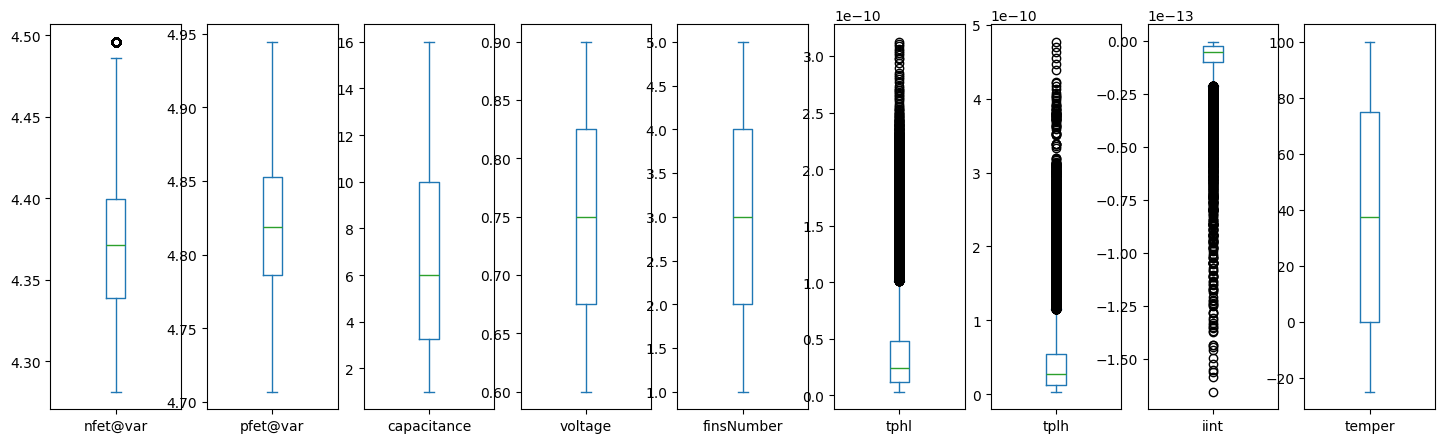

<Figure size 640x480 with 0 Axes>

In [9]:
data.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

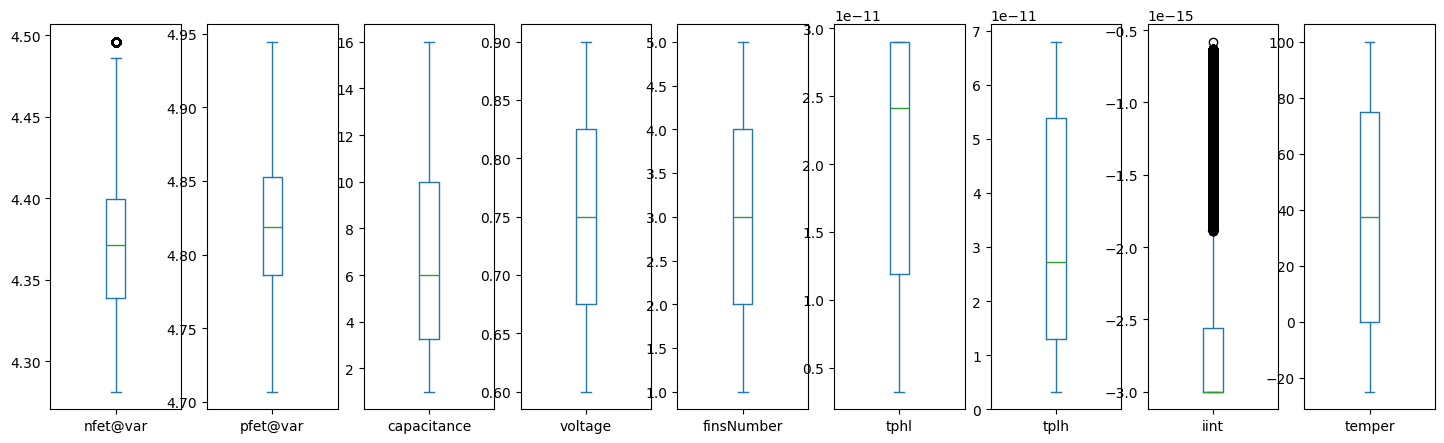

<Figure size 640x480 with 0 Axes>

In [10]:
# Outliers
#data = data[(2e-12<=data.tphl)&(data.tphl<=2.9e-11)]
#data = data[(1e-12<=data.tplh)&(data.tplh<=6.8e-11)]
#data = data[(-3e-15<=data.iint)]

data['tphl'] = data['tphl'].clip(lower=2e-12, upper=2.9e-11)
data['tplh'] = data['tplh'].clip(lower=1e-12, upper=6.8e-11)
data['iint'] = data['iint'].clip(lower=-3e-15)

data.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

- count: number of non-null values (155.077)
- mean: average value
- std: stadard deviation (how spread out the data is)
- min/max: range
- 25%, 50%, 75%: percentiles, where 50% is median

## Exploratory Data Plots



Inputs (5 total)
x = [nmos@fet, pmos@fet, temper*, voltage, finsNumber]

Outputs (3 total)
y = [tphl, tplh, iint]

Variables (8 total)

- **nmos@fet**: NMOS transistor process variation parameter for the FinFET device
- **pmos@fet**: PMOS transistor process variation parameter for the FinFET device
- **tphl**: propagation delay from output High to Low
- **tplh**: propagation delay from output Low to High
- **iint**: energy dissipated by the circuit
- **voltage**: supply voltage (VDD)
- **capacitance**:  load capacitance at the inverter output
- **finsNumber** number of fins in the FinFET transistor structure
- **Temper**: operating temperature of the circuit

Units
- **nfet@var**: Joule #confirmar
- **pfet@var**: Joule função trabalho #confirmar
- **tphl**:	Seconds (s)
- **tplh**: Seconds (s)
- **iint**:	Amperes (A)
- **voltage**: Volts (V)
- **capacitance**: Farads (F)
- **finsNumber**: unitless
- **temper**: Celsius (°C)

There aren't fixed variables values

- **nfet@var**: 100 different values
- **pfet@var**: 100 different values
- **tphl**: 35.369 different values
- **tplh**: 35.463 different values
- **iint**: 44.144 different values
- **voltage**: 4 different values (0.6, 0.7, 0.8, 0.9)
- **capacitance**: 4 different values (1, 4, 8, 16)
- **finsNumber**: 5 different values (1, 2, 3, 4, 5)
- **temper**: 6 different values (-25, 0, 25, 50, 75, 100)

In [ ]:
data["voltage"].value_counts()

In [ ]:
data["capacitance"].value_counts()

In [ ]:
#why there's only two values of capacitance?? outliers?

In [ ]:
data["finsNumber"].value_counts()

In [ ]:
data["temper"].value_counts()

In [ ]:
data.nunique()

In [ ]:
data.describe(include="all")

In [ ]:
data.shape

In [ ]:
output_vars = ['tphl', 'tplh', 'iint']

variance_results = data[output_vars].var()
std_dev_results = data[output_vars].std()

eda_summary = pd.DataFrame({
    'Variance': variance_results,
    'Standard Deviation': std_dev_results
})

print(eda_summary)

In [ ]:
# Correlation
ax = sns.heatmap(data.corr(numeric_only=True), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
ax.set_title('Correlation between all variables in the dataset')
ax=ax
plt.show()
plt.savefig(f"{plots_dir}/correlation.png")
plt.close()

In [ ]:
data.corr()

In [ ]:
#Boxplot
variables = ['capacitance', 'voltage', 'finsNumber', 'temper']
cols = [c for c in data.columns if 'length' not in c.lower() and c not in variables]
axes = data[cols].plot(kind='box', figsize=(20,5), subplots=True, layout=(1, len(cols)))
plt.show()
plt.savefig(f"{plots_dir}/boxplot.png")
plt.close()

In [ ]:
cols = ['capacitance', 'voltage', 'finsNumber', 'temper']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(cols):
    counts = data[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig(f"{plots_dir}/count_plot.png")
plt.close()

In [ ]:
data[['nfet@var', 'pfet@var', 'tphl', 'tplh', 'iint']].hist(
    bins=50, 
    figsize=(15, 10), 
    layout=(3, 2)
)

plt.savefig(f"{plots_dir}/histogram.png")
plt.show()
plt.close()

In [ ]:
plt.plot('nfet@var', 'pfet@var', data=data, linestyle='none', marker='D', markersize=2)
plt.title('PFET vs NFET scatter plot')
plt.show()
plt.savefig(f"{plots_dir}/scatter_plot.png")
plt.close()